### Overview

Permutation importance analysis of Rank-SVM on SCAN-B NextSeq test set (semi-external validation set)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import scipy.stats as stats
from sklearn import metrics
import random
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Import and prepare input data

In [2]:
# import tpm counts training set
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [3]:
# import external validation data
val_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_tpm_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)

In [4]:
# keep only PAM50 genes
X_train = train_data.iloc[:, 0:50]
X_test = val_data.iloc[:,0:50]
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(2204, 50)
(276, 50)
True


In [5]:
# import PAM50 file
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [6]:
# check for match
print(X_train.columns.tolist() == pam50['ensembl_gene_id'].tolist())
print(X_test.columns.tolist() == pam50['ensembl_gene_id'].tolist())

True
True


In [7]:
# rename the columns
X_train.columns = pam50['new_gene_symbol']
X_test.columns = pam50['new_gene_symbol']

In [8]:
# save sample subtype info separately as y_train and y_test
y_train = train_data.iloc[:, [50]]
y_test = val_data.iloc[:,[50]]
print(y_train.shape)
print(y_test.shape)

(2204, 1)
(276, 1)


In [9]:
# check if the indices of x and y match
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


In [10]:
# label encoding of Y_train
label_encoder = LabelEncoder()
y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
y_test['subtype'] = label_encoder.transform(y_test['subtype'])

# check class count before label encoding
print("Class count before label encoding")
print("Train set\n",train_data['subtype'].value_counts())
print("\nTest set\n",val_data['subtype'].value_counts())

# check class count after label encoding
print("\nClass count after label encoding")
print("Train set\n",y_train['subtype'].value_counts())
print("\nTest set\n",y_test['subtype'].value_counts())

Class count before label encoding
Train set
 subtype
LumA     1119
LumB      654
Basal     230
Her2      201
Name: count, dtype: int64

Test set
 subtype
LumA     142
LumB      78
Basal     29
Her2      27
Name: count, dtype: int64

Class count after label encoding
Train set
 subtype
2    1119
3     654
0     230
1     201
Name: count, dtype: int64

Test set
 subtype
2    142
3     78
0     29
1     27
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_8424\3767406850.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
C:\Users\User\AppData\Local\Temp\ipykernel_8424\3767406850.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['subtype'] = label_encoder.transform(y_test['subtype'])


In [11]:
# replace gene values by the rank
X_train_ranked = X_train.rank(axis=1, method="min", ascending=False).astype('int')
X_test_ranked = X_test.rank(axis=1, method="min", ascending=False).astype('int')

In [12]:
# scale the ranks between 0 and 1 for each sample
max_rank = len(X_train.columns)
X_train_ranked_scaled = X_train_ranked.apply(lambda row: (row-1) / (max_rank-1), axis=1)
X_test_ranked_scaled = X_test_ranked.apply(lambda row: (row-1) / (max_rank-1), axis=1)

In [13]:
print(X_train_ranked_scaled.shape)
print(X_test_ranked_scaled.shape)

(2204, 50)
(276, 50)


In [14]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 2. Rank-SVM Classification

In [15]:
random.seed(seed)
np.random.seed(seed)
    
# build svm classifier
svm = SVC(C=1, gamma=1, kernel='rbf', random_state=seed)

# fit the rfc model on the training fold sets
svm.fit(X_train_ranked_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_svm = svm.predict(X_test_ranked_scaled)

# calculate metric scores
mcc_svm = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_svm)
f1_svm = metrics.f1_score(y_test.values.ravel(), y_pred_svm, average='macro')
recall_svm = metrics.recall_score(y_test.values.ravel(), y_pred_svm, average='macro')
precision_svm = metrics.precision_score(y_test.values.ravel(), y_pred_svm, average='macro')
accuracy_svm = metrics.accuracy_score(y_test.values.ravel(), y_pred_svm)

print(metrics.classification_report(y_test.values.ravel(), y_pred_svm, digits=4))


              precision    recall  f1-score   support

           0     1.0000    0.9655    0.9825        29
           1     0.9286    0.9630    0.9455        27
           2     0.9437    0.9437    0.9437       142
           3     0.8974    0.8974    0.8974        78

    accuracy                         0.9348       276
   macro avg     0.9424    0.9424    0.9423       276
weighted avg     0.9350    0.9348    0.9348       276



In [16]:
print('Accuracy: ', round(accuracy_svm,4))
print('Macro Precision: ', round(precision_svm,4))
print('Macro Recall: ', round(recall_svm,4))
print('Macro F1: ', round(f1_svm,4))
print('Macro MCC: ', round(mcc_svm,4))

Accuracy:  0.9348
Macro Precision:  0.9424
Macro Recall:  0.9424
Macro F1:  0.9423
Macro MCC:  0.8973


#### 3. Spearman Rank Correlation

In [17]:
# Compute pairwise Spearman correlation (better for rank data than Pearson)
test_corr_matrix = pd.DataFrame(X_test_ranked_scaled).corr(method='spearman')

In [18]:
# Find all pairs with high correlation
high_corr_pairs = []
for i in range(len(test_corr_matrix.columns)):
    for j in range(i+1, len(test_corr_matrix.columns)):
        r = test_corr_matrix.iloc[i, j]
        if abs(r) >= 0.7:
            high_corr_pairs.append({
                'gene1': test_corr_matrix.columns[i],
                'gene2': test_corr_matrix.columns[j],
                'spearman_r': round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('spearman_r', 
                                                           ascending=False)

In [19]:
high_corr_df

,gene1,gene2,spearman_r
12,KRT14,KRT5,0.868
14,KRT17,KRT5,0.828
4,CDC20,KIF2C,0.817
3,BIRC5,UBE2C,0.796
11,KRT14,KRT17,0.794
13,KRT14,MIA,0.778
20,MYBL2,UBE2C,0.778
10,KIF2C,UBE2C,0.770
19,MKI67,UBE2C,0.766
6,CDC20,UBE2C,0.762


#### 4. Permutation Feature Importance 

In [20]:
score_f1 = metrics.make_scorer(metrics.f1_score, average='macro')

In [21]:
svm_permutation = permutation_importance(svm, X_test_ranked_scaled, y_test, n_repeats=50, scoring=score_f1,
                                         random_state=seed)

In [22]:
# organize the importance of features as a df and sort the features by importance score in descending order
svm_feature_importance = pd.DataFrame({'gene': X_test_ranked_scaled.columns, 
                                       'importance_score': svm_permutation.importances_mean,
                                      'importance_std': svm_permutation.importances_std})
svm_feature_importance = svm_feature_importance.sort_values(ascending=False, by='importance_score').reset_index(drop=True)

# select top 10 
top10 = svm_feature_importance.iloc[0:10]
top10

,gene,importance_score,importance_std
0,ESR1,0.028536,0.010294
1,SFRP1,0.019075,0.010891
2,TMEM45B,0.018477,0.009879
3,FGFR4,0.015607,0.008635
4,EGFR,0.013945,0.007294
5,FOXC1,0.011129,0.008821
6,FOXA1,0.010723,0.005085
7,MAPT,0.010374,0.007521
8,CDH3,0.008335,0.008769
9,GRB7,0.007334,0.008236


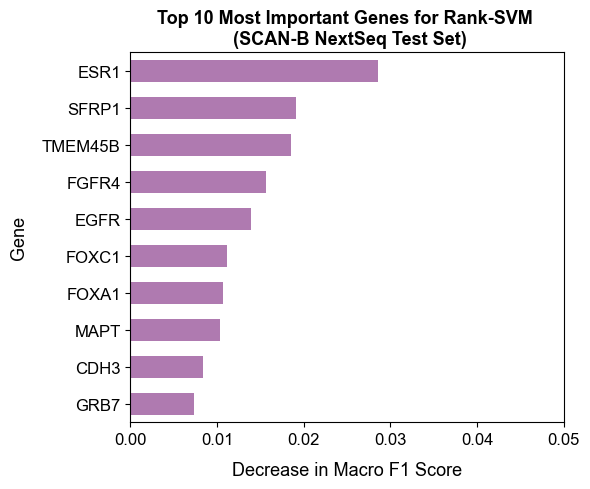

In [30]:
# permutation importance plot
plt.figure(figsize=(6, 5))
sns.barplot(x=top10['importance_score'], y=top10['gene'], color='#b871b9', width=0.6)
plt.title('Top 10 Most Important Genes for Rank-SVM \n (SCAN-B NextSeq Test Set)',
    fontdict={'size': 13, 'color': 'black', 'family': 'Arial', 'weight': 'bold'})
plt.xlabel('Decrease in Macro F1 Score', fontdict={'size': 13, 'color': 'black', 'family': 'Arial'}, labelpad=10)
plt.ylabel('Gene', fontdict={'size': 13, 'color': 'black', 'family': 'Arial'},labelpad=10)
plt.xticks(fontsize=12, color='black', fontfamily='Arial')
plt.yticks(fontsize=12, color='black', fontfamily='Arial')
plt.xlim(0, 0.05)
plt.tight_layout()
plt.savefig('scanb_nextseq_test_rank_svm_permutation.png', dpi=300, bbox_inches='tight')
plt.show()